In [40]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    losses,
    optimizers,
)

from scipy.stats import norm
import pandas as pd

from utils import sample_batch, display

from vae_utils import get_vector_from_label, add_vector_to_images, morph_faces

In [2]:
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE = 51
NUM_FEATURES = 32
Z_DIM = 20
LEARNING_RATE = 0.0005
EPOCHS = 50
BETA = 2000

In [3]:
# Load the data
train_data = utils.image_dataset_from_directory(
    r"C:\Users\E2021593.CEET\Desktop\Lithium Microstructures",
    labels=None,
    color_mode="rgb",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    interpolation="bilinear",
)

Found 100000 files.


In [4]:
# Preprocess the data
def preprocess(img):
    img = tf.cast(img, "float32") / 255.0
    return img


train = train_data.map(lambda x: preprocess(x))

In [5]:
train_sample = sample_batch(train)

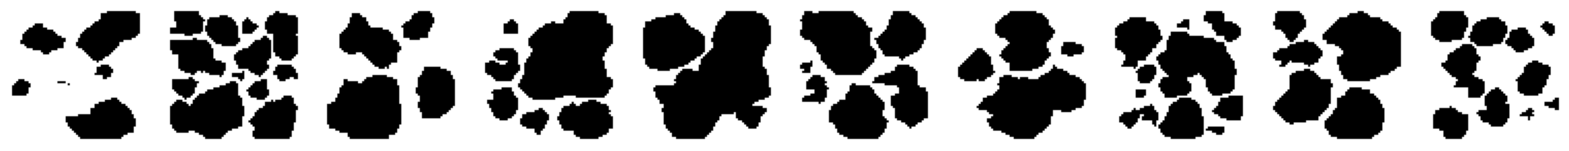

In [6]:
# Show some faces from the training set
display(train_sample, cmap=None)

In [7]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [8]:
# Encoder
encoder_input = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), name="encoder_input"
)
#Block 1
x = layers.Conv2D(NUM_FEATURES, kernel_size=3, strides=2, padding="same")(
    encoder_input
)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
#Block 2 
x = layers.Conv2D(NUM_FEATURES, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
#Block 3
x = layers.Conv2D(NUM_FEATURES, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
# Block 4
x = layers.Conv2D(NUM_FEATURES, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
# Block 5
x = layers.Conv2D(NUM_FEATURES, kernel_size=3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Save the shape before flattening (required for the decoder)
shape_before_flattening = K.int_shape(x)[1:]  # the decoder will need this!

# Latent space
x = layers.Flatten()(x)
z_mean = layers.Dense(Z_DIM, name="z_mean")(x)
z_log_var = layers.Dense(Z_DIM, name="z_log_var")(x)

# Sampling layer
z = Sampling()([z_mean, z_log_var])

# Define the encoder model and model summary
encoder = models.Model(encoder_input, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)    │ (None, 64, 64, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 32, 32, 32)        │             896 │ encoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 32, 32, 32)        │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu (LeakyReLU)       │ (None, 32, 32, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 16, 16, 32)        │           9,248 │ leaky_re_lu[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 16, 16, 32)        │             128 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)     │ (None, 16, 16, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 8, 8, 32)          │           9,248 │ leaky_re_lu_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 8, 8, 32)          │             128 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU)     │ (None, 8, 8, 32)          │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 4, 4, 32)          │           9,248 │ leaky_re_lu_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 4, 4, 32)          │             128 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)     │ (None, 4, 4, 32)          │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 2, 2, 32)          │           9,248 │ leaky_re_lu_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 2, 2, 32)          │             128 │ conv2d_4[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 43,688 (170.66 KB)

 Trainable params: 43,368 (169.41 KB)

 Non-trainable params: 320 (1.25 KB)

In [14]:
# Decoder
decoder_input = layers.Input(shape=(Z_DIM,), name="decoder_input")

# Block 1: Dense layer to reshape back to the feature map
x = layers.Dense(np.prod(shape_before_flattening))(decoder_input)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)
x = layers.Reshape(shape_before_flattening)(x)

# Block 2: Conv2DTranspose Layer 1
x = layers.Conv2DTranspose(
    NUM_FEATURES, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 3: Conv2DTranspose Layer 2
x = layers.Conv2DTranspose(
    NUM_FEATURES, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 4: Conv2DTranspose Layer 3
x = layers.Conv2DTranspose(
    NUM_FEATURES, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 5: Conv2DTranspose Layer 4
x = layers.Conv2DTranspose(
    NUM_FEATURES, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Block 6: Conv2DTranspose Layer 5
x = layers.Conv2DTranspose(
    NUM_FEATURES, kernel_size=3, strides=2, padding="same"
)(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Final Block: Output Layer
decoder_output = layers.Conv2DTranspose(
    CHANNELS, kernel_size=3, strides=1, activation="sigmoid", padding="same"
)(x)

# Define the decoder model and model summary
decoder = models.Model(decoder_input, decoder_output)
decoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)           │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_10 (LeakyReLU)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 2, 2, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_5 (Conv2DTranspose) │ (None, 4, 4, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 4, 4, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_11 (LeakyReLU)           │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_6 (Conv2DTranspose) │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_12 (LeakyReLU)           │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_7 (Conv2DTranspose) │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_13 (LeakyReLU)           │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_8 (Conv2DTranspose) │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_14 (LeakyReLU)           │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_9 (Conv2DTranspose) │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 64, 64, 32)          │             1

 Total params: 50,947 (199.01 KB)

 Trainable params: 50,371 (196.76 KB)

 Non-trainable params: 576 (2.25 KB)

In [20]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        """Call the model on a particular input."""
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return z_mean, z_log_var, reconstruction

    def mean_squared_error(self, y_true, y_pred):
        return tf.reduce_mean(tf.square(y_true - y_pred))

    def train_step(self, data):
        """Step run during training."""
        with tf.GradientTape() as tape:
            z_mean, z_log_var, reconstruction = self(data, training=True)
            reconstruction_loss = tf.reduce_mean(
                BETA * self.mean_squared_error(data, reconstruction)
            )
            kl_loss = tf.reduce_mean(
                tf.reduce_sum(
                    -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                    axis=1,
                )
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }



In [21]:
# Create a variational autoencoder
vae = VAE(encoder, decoder)

In [22]:
# Compile the variational autoencoder
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)
vae.compile(optimizer=optimizer)

In [23]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint.keras",
    save_weights_only=False,
    save_freq="epoch",
    monitor="loss",
    mode="min",
    save_best_only=True,
    verbose=0,
)

In [24]:
vae.fit(
    train,
    epochs=EPOCHS,
    callbacks=[
        model_checkpoint_callback,
    ],
)

Epoch 1/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 194s 95ms/step - kl_loss: 22.8879 - loss: 322.7978 - reconstruction_loss: 299.9098
Epoch 2/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 143s 73ms/step - kl_loss: 32.0934 - loss: 248.0560 - reconstruction_loss: 215.9626
Epoch 3/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 147s 75ms/step - kl_loss: 32.7008 - loss: 243.0117 - reconstruction_loss: 210.3109
Epoch 4/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 145s 74ms/step - kl_loss: 33.2103 - loss: 240.2920 - reconstruction_loss: 207.0815
Epoch 5/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 143s 73ms/step - kl_loss: 33.6304 - loss: 238.3103 - reconstruction_loss: 204.6798
Epoch 6/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 142s 73ms/step - kl_loss: 33.9441 - loss: 236.9482 - reconstruction_loss: 203.0038
Epoch 7/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 141s 72ms/step - kl_loss: 34.1784 - loss: 235.8247 - reconstruction_loss: 201.6462
Epoch 8/50
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 140s 71ms/step - kl_loss: 34.3709 - loss: 234.9180 - reconstruction_loss: 200.5473


In [26]:
# Select a subset of the test set
batches_to_predict = 1
example_images = np.array(
    list(train.take(batches_to_predict).get_single_element())
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step
Example real Structures


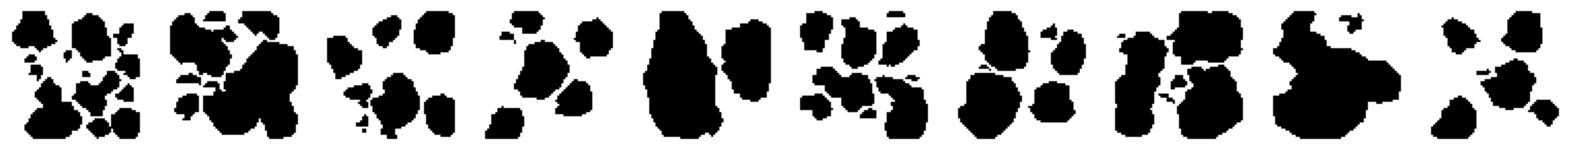

Reconstructions


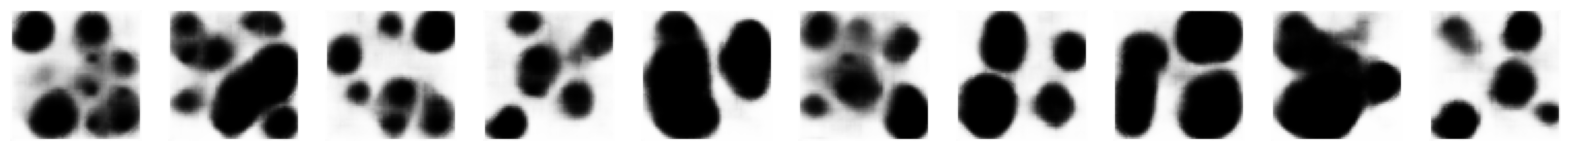

In [27]:
# Create autoencoder predictions and display
z_mean, z_log_var, reconstructions = vae.predict(example_images)
print("Example real Structures")
display(example_images)
print("Reconstructions")
display(reconstructions)

In [29]:
# Sample some points in the latent space, from the standard normal distribution
grid_width, grid_height = (10, 3)
z_sample = np.random.normal(size=(grid_width * grid_height, Z_DIM))

In [30]:
# Decode the sampled points
reconstructions = decoder.predict(z_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


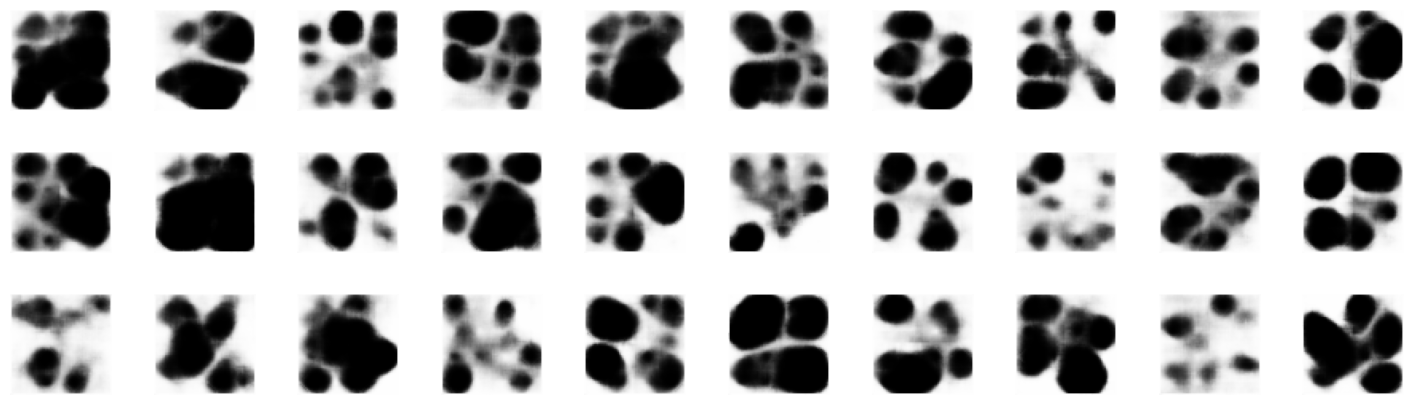

In [31]:
# Draw a plot of decoded images
fig = plt.figure(figsize=(18, 5))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

# Output the grid of faces
for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.imshow(reconstructions[i, :, :])

In [37]:
import pandas as pd
# Load the label dataset
attributes = pd.read_csv(r"C:\Users\E2021593.CEET\Desktop\Microstructure\area.csv")
print(attributes.columns)
attributes.head()

Index(['Image Name', 'Pore Percentage', 'Solid Percentage', 'Low Pore',
       'Low-Medium Pore', 'High-Medium Pore', 'High Pore', 'Low Solid',
       'Low-Medium Solid', 'High-Medium Solid', 'High Solid'],
      dtype='object')


,Image Name,Pore Percentage,Solid Percentage,Low Pore,Low-Medium Pore,High-Medium Pore,High Pore,Low Solid,Low-Medium Solid,High-Medium Solid,High Solid
0,0.png,37.23,62.77,-1,1,-1,-1,-1,-1,1,-1
1,1.png,43.24,56.76,-1,1,-1,-1,-1,-1,1,-1
2,10.png,35.47,64.53,-1,1,-1,-1,-1,-1,1,-1
3,100.png,63.50,36.50,-1,-1,1,-1,-1,1,-1,-1
4,1000.png,28.88,71.12,-1,1,-1,-1,-1,-1,1,-1


In [38]:
LABEL = "High Solid"  # Set this label
labelled_test = utils.image_dataset_from_directory(
    r"C:\Users\E2021593.CEET\Desktop\Lithium Microstructures",
    labels=attributes[LABEL].tolist(),
    color_mode="rgb",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation",
    interpolation="bilinear",
)

labelled = labelled_test.map(lambda x, y: (preprocess(x), y))

Found 100000 files belonging to 2 classes.
Using 20000 files for validation.


In [41]:
# Find the attribute vector
attribute_vec = get_vector_from_label(labelled, vae, Z_DIM, LABEL)

label: High Solid
images : POS move : NEG move :distance : 𝛥 distance
2    : 3.782    : 0.684    : 3.987    : 3.987
2    : 3.782    : 0.488    : 3.946    : -0.041
2    : 3.782    : 0.245    : 3.983    : 0.036
2    : 3.782    : 0.172    : 3.923    : -0.06
2    : 3.782    : 0.14    : 3.884    : -0.039
2    : 3.782    : 0.143    : 3.879    : -0.005
2    : 3.782    : 0.075    : 3.866    : -0.013
2    : 3.782    : 0.069    : 3.846    : -0.02
2    : 3.782    : 0.073    : 3.864    : 0.017
2    : 3.782    : 0.082    : 3.836    : -0.027
2    : 3.782    : 0.056    : 3.83    : -0.006
3    : 1.416    : 0.048    : 3.444    : -0.386
5    : 0.542    : 0.043    : 3.52    : 0.076
5    : 0.542    : 0.048    : 3.497    : -0.023
5    : 0.542    : 0.04    : 3.494    : -0.003
5    : 0.542    : 0.034    : 3.489    : -0.005
5    : 0.542    : 0.023    : 3.501    : 0.012
5    : 0.542    : 0.033    : 3.502    : 0.001
5    : 0.542    : 0.039    : 3.507    : 0.005
6    : 0.452    : 0.031    : 3.529    : 0.022
6   

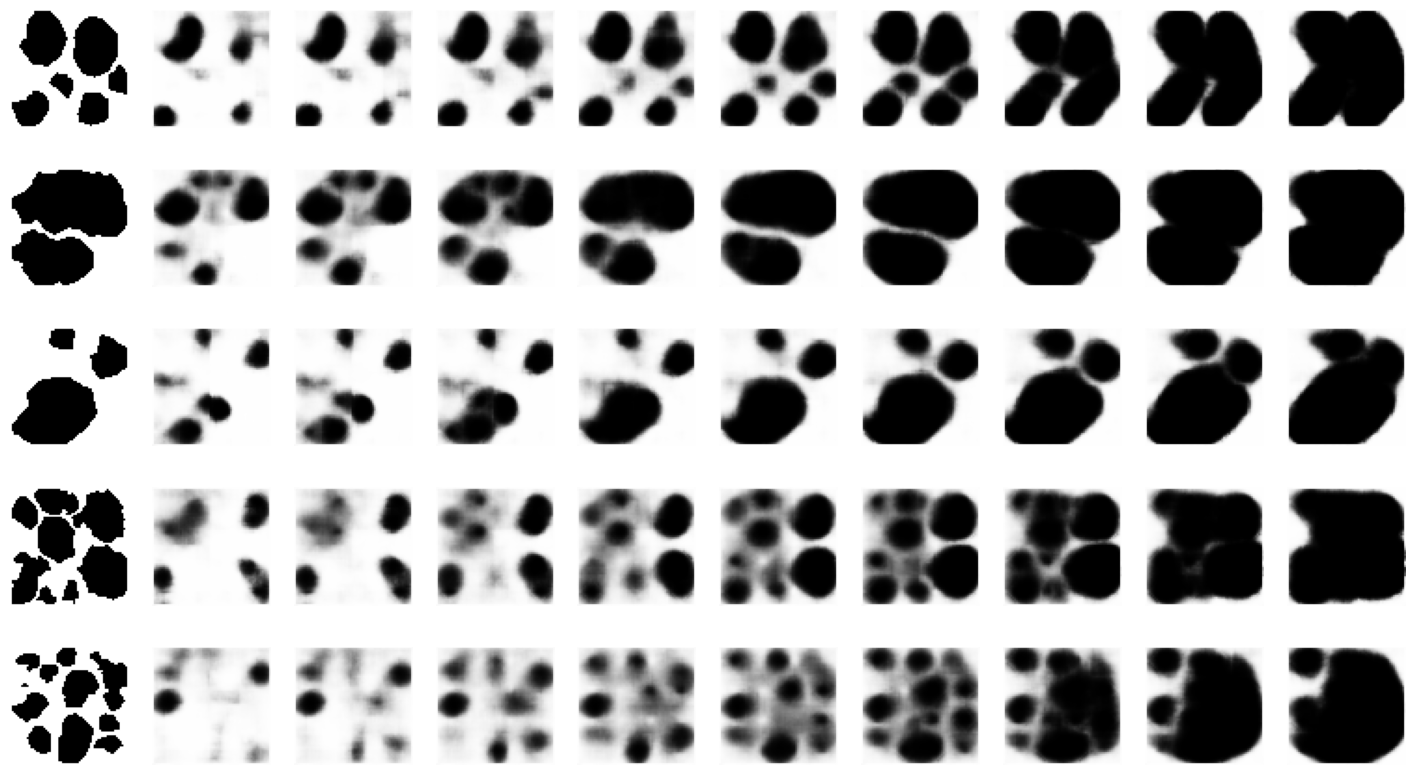

In [43]:
# Add vector to images
add_vector_to_images(labelled, vae, attribute_vec)

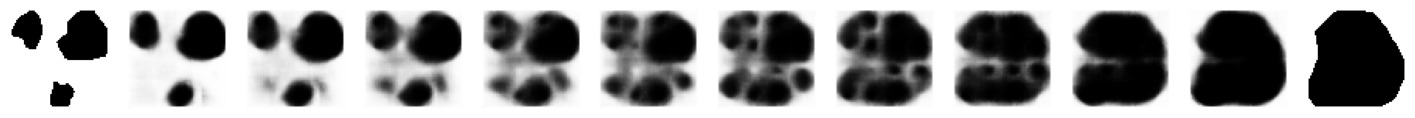

In [44]:
morph_faces(labelled, vae)